In [1]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [9]:
%matplotlib inline

In [10]:
data = sio.loadmat('data/data.mat', squeeze_me=True, struct_as_record=False)['data']
print(len(data))

80788


In [11]:
type(data)

numpy.ndarray

In [5]:
type(data[0])

scipy.io.matlab._mio5_params.mat_struct

In [6]:
type(data[0].boundary)

numpy.ndarray

In [7]:
data[2].name

'10'

In [12]:
name_to_index = { floorPlan.name : i for i, floorPlan in enumerate(data) }

# Draw floor plan

In [13]:
def draw_boundary(floorPlan):
    # Plotting a boundary

    start = 2
    end = floorPlan.boundary.shape[0]

    x = floorPlan.boundary[start:end, 0]
    y = floorPlan.boundary[start:end, 1]

    if floorPlan.boundary[0, 3] == 0:
        x = np.append(x, floorPlan.boundary[0, 0])
        y = np.append(y, floorPlan.boundary[0, 1])

    if floorPlan.boundary[1, 3] == 0:
        x = np.append(x, floorPlan.boundary[1, 0])
        y = np.append(y, floorPlan.boundary[1, 1])
    

    x = np.append(x, floorPlan.boundary[2, 0])
    y = np.append(y, floorPlan.boundary[2, 1])

    plt.plot(x, y)

    # Plotting doors

    end = 2
    start = 0

    x = floorPlan.boundary[start:end, 0]
    y = floorPlan.boundary[start:end, 1]


    plt.plot(x, y, marker = 'o')

    plt.axis('equal')
    plt.grid()
    plt.gca().invert_yaxis()

    plt.title(f'Floor plan {floorPlan.name}')

    plt.show()

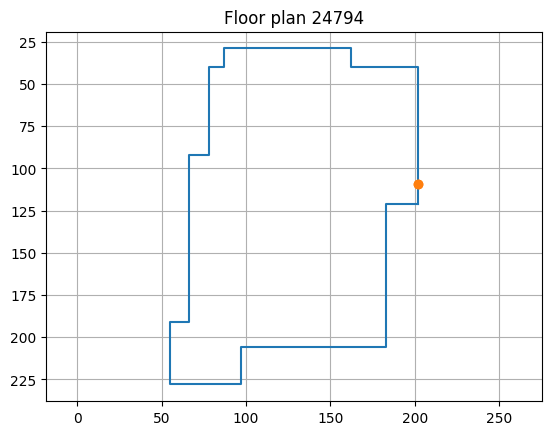

In [16]:
draw_boundary(data[name_to_index['24794']])

In [11]:
room_label = [
    (0, 'LivingRoom', 1, "PublicArea"),
    (1, 'MasterRoom', 0, "Bedroom"),
    (2, 'Kitchen', 1, "FunctionArea"),
    (3, 'Bathroom', 0, "FunctionArea"),
    (4, 'DiningRoom', 1, "FunctionArea"),
    (5, 'ChildRoom', 0, "Bedroom"),
    (6, 'StudyRoom', 0, "Bedroom"),
    (7, 'SecondRoom', 0, "Bedroom"),
    (8, 'GuestRoom', 0, "Bedroom"),
    (9, 'Balcony', 1, "PublicArea"),
    (10, 'Entrance', 1, "PublicArea"),
    (11, 'Storage', 0, "PublicArea"),
    (12, 'Wall-in', 0, "PublicArea"),
]

In [12]:
def draw_room_boundary(floorPlan):

    for room in floorPlan.rBoundary:
        x = room[:, 0]
        y = room[:, 1]

        x = np.append(x, room[0, 0])
        y = np.append(y, room[0, 1])

        plt.plot(x, y)

    plt.grid()
    plt.ylim(0, 250)
    plt.xlim(0, 250)
    plt.gca().invert_yaxis()

    plt.title(f'Floor plan {floorPlan.name}')

    plt.show()

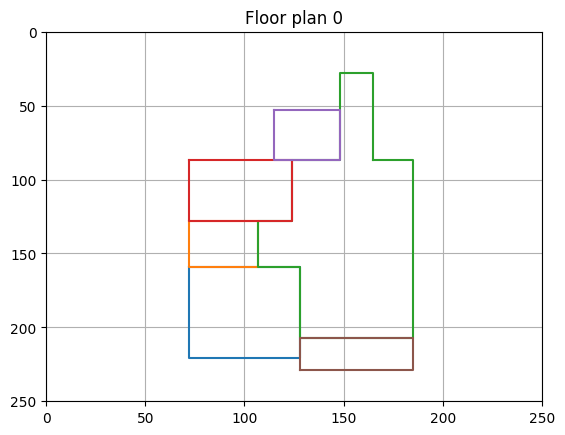

In [13]:
draw_room_boundary(data[0])

In [14]:
def draw_rooms(floorPlan):
    roomsNb = len(floorPlan.rType)

    fig, axes = plt.subplots(3, roomsNb, figsize=(roomsNb*3, 3*4))

    for i, boundary in enumerate(floorPlan.rBoundary):
        # Drawing room boundary
        x = boundary[:, 0]
        y = boundary[:, 1]

        x = np.append(x, boundary[0, 0])
        y = np.append(y, boundary[0, 1])

        axes[0, i].plot(x, y)

        axes[0, i].grid()
        axes[0, i].set_ylim(250, 0)
        axes[0, i].set_xlim(0, 250)

        room_name = room_label[floorPlan.rType[i]][1]
        axes[0, i].set_title(f'{room_name} boundary')

    for i, box in enumerate(floorPlan.gtBox[:-1]):
        # Draw bbox
        width = box[3] - box[1]
        height = box[2]-box[0]

        rect = patches.Rectangle((box[1], box[0]), width, height)

        axes[1, i].add_patch(rect)
        axes[1, i].grid()
        axes[1, i].set_ylim(250, 0)
        axes[1, i].set_xlim(0, 250)

        room_name = room_label[floorPlan.rType[i]][1]
        axes[1, i].set_title(f'{room_name} box - RPLAN')

    for i, box in enumerate(floorPlan.gtBoxNew[:-1]):
        # Draw bbox
        width = box[3] - box[1]
        height = box[2]-box[0]

        rect = patches.Rectangle((box[1], box[0]), width, height)

        axes[2, i].add_patch(rect)
        axes[2, i].grid()
        axes[2, i].set_ylim(250, 0)
        axes[2, i].set_xlim(0, 250)

        room_name = room_label[floorPlan.rType[i]][1]
        axes[2, i].set_title(f'{room_name} box new - Graph2Plan')

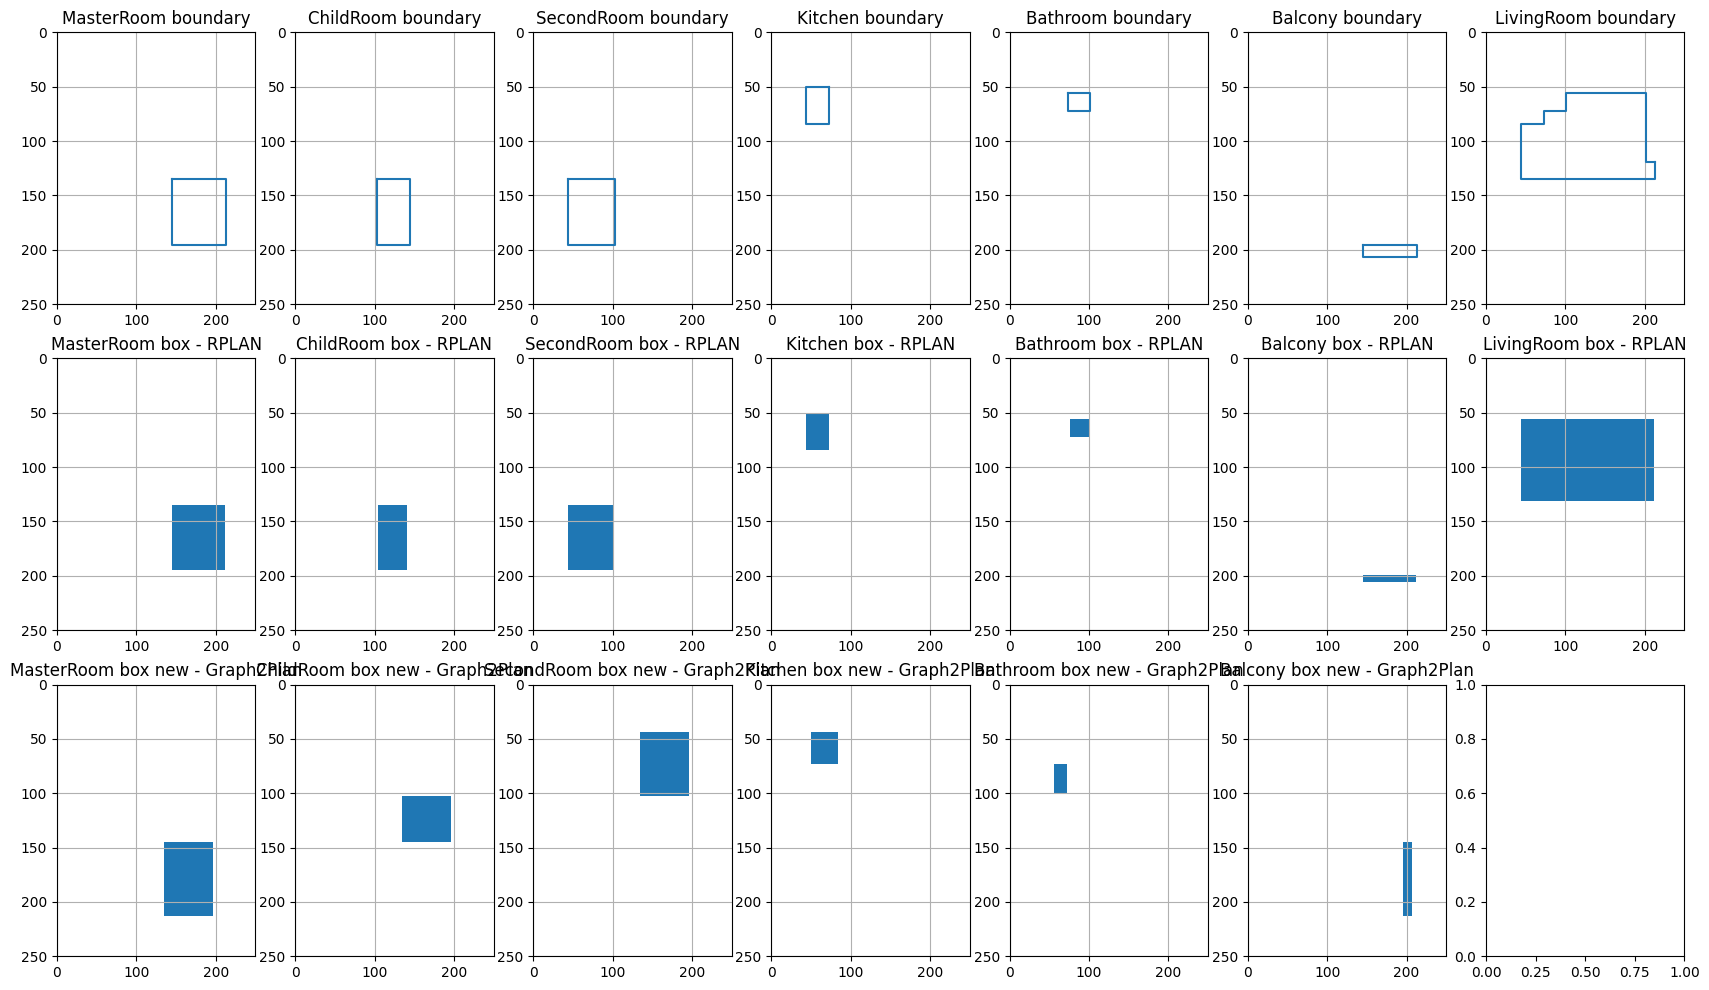

In [15]:
draw_rooms(data[1])

In [16]:
len(data[0].gtBox)

7

In [17]:
planIndex = 0
roomIndex = 5

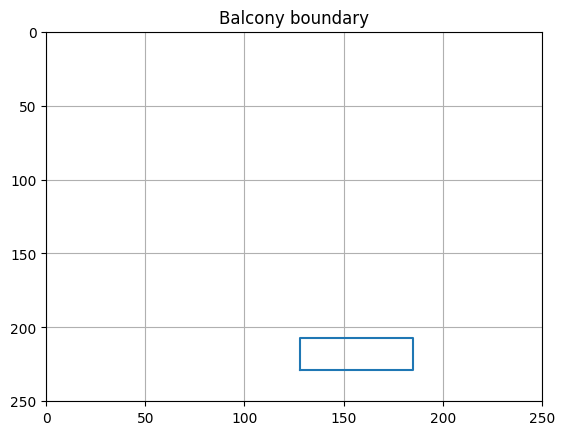

In [18]:
room = data[planIndex].rBoundary[roomIndex]

x = room[:, 0]
y = room[:, 1]

x = np.append(x, room[0, 0])
y = np.append(y, room[0, 1])

plt.plot(x, y)

plt.grid()
plt.ylim(0, 250)
plt.xlim(0, 250)
plt.gca().invert_yaxis()

plt.title(f'{room_label[data[planIndex].rType[roomIndex]][1]} boundary')

plt.show()

Text(0.5, 1.0, 'Balcony box')

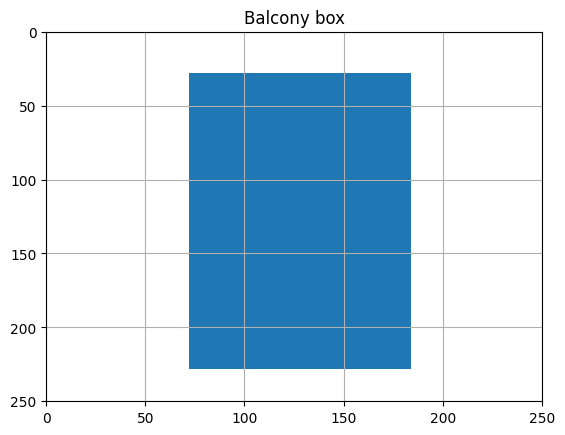

In [19]:
room = data[planIndex].gtBox[6]

rect = patches.Rectangle((room[1], room[0]), room[3] - room[1], room[2]-room[0])

fig, ax = plt.subplots()

ax.add_patch(rect)

plt.grid()
plt.ylim(0, 250)
plt.xlim(0, 250)
plt.gca().invert_yaxis()

plt.title(f'{room_label[data[planIndex].rType[roomIndex]][1]} box')

In [20]:
data[0].gtBox

array([[161,  72, 220, 124],
       [130,  72, 157, 107],
       [ 28, 111, 203, 184],
       [ 87,  72, 126, 124],
       [ 53, 115,  83, 144],
       [207, 128, 228, 184],
       [ 28,  72, 228, 184]], dtype=int32)

# Number of room types

In [21]:
rooms_cnt = np.zeros(len(room_label), dtype=np.int32)
rooms_cnt.shape

(13,)

In [22]:
for floorPlan in data:
    for room in floorPlan.rType:
        rooms_cnt[room] += 1

In [23]:
room_names = []

for room_desc in  room_label:
    room_names.append(room_desc[1])

len(room_names)

13

<BarContainer object of 13 artists>

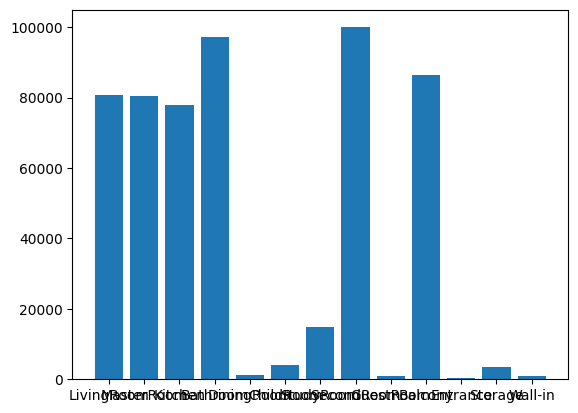

In [24]:
plt.bar(room_names, rooms_cnt)

In [25]:
rooms_cnt

array([80788, 80466, 77768, 97113,  1312,  3928, 14985, 99987,   860,
       86545,   292,  3351,  1043], dtype=int32)

# Max corners count

In [2]:
from src.mat_file import from_mat_file
from src.dataset_loader import load_dataset_from_mat_file

from src.floor_plan import RoomType, FloorPlan, Room

from src.drawing import draw_floor_plan

/home/pnieck/Repos/FloorPlanGen/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data = load_dataset_from_mat_file("data/data.mat")
floor_plans = []

for plan in data:
    floor_plans.append(from_mat_file(plan))

In [4]:
len(floor_plans)

80405

In [29]:
max_corners = 0

for plan in floor_plans:
    if max_corners < plan.corners_cnt:
        max_corners = plan.corners_cnt

    for room in plan.rooms:
        if max_corners < room.corners_cnt:
            max_corners = room.corners_cnt

max_corners

58

# Floor plans with wall ins

In [30]:
with_wall_in = set()

for plan in floor_plans:
    wall_ins = plan.rooms_of_type(RoomType.WallIn)
    if wall_ins:
        with_wall_in.add(plan)

In [31]:
len(with_wall_in)

1024

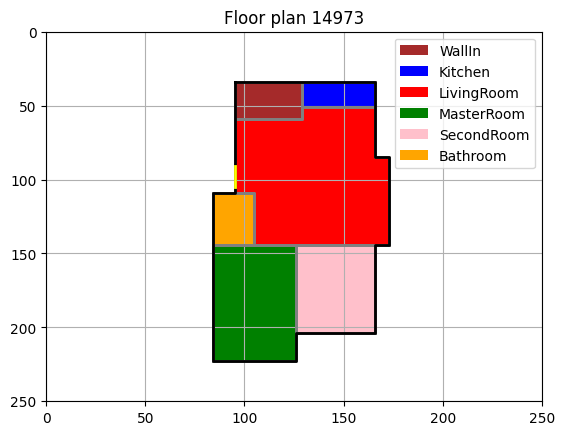

In [32]:
draw_floor_plan(next(iter(with_wall_in)))

# Dataset validation

In [33]:
from src.validation_metrics import (
    CoverageTest,
    GeomValidityRate,
    RoomsOverlappingTest,
    RequiredRoomsTest,
    NarrowSpacesTest,
    GeometrySimplicityTest,
    RoomsNeighborhoodTest,
    ErgonomicsTest
)

In [34]:
validity_rate = GeomValidityRate()
geom_simplicity = GeometrySimplicityTest()
cov_rate = CoverageTest()
room_overlap_rate = RoomsOverlappingTest()
required_rooms = RequiredRoomsTest()
narrow_spaces = NarrowSpacesTest()
neighborhood = RoomsNeighborhoodTest()
ergo = ErgonomicsTest()

floor_plans = validity_rate.filter_out_invalid(floor_plans)
print(f"Validity rate {validity_rate.rate()}")

geom_simplicity.simplify(floor_plans)
print(f"Geometry simplicity rate {geom_simplicity.rate()}")

cov_rate.measure(floor_plans)
print(f"Fully covered floor plans: {cov_rate.correct_floor_plans}/{cov_rate.examples_cnt}")

room_overlap_rate.measure(floor_plans)
print(f"Floor plans with no overlapping rooms: {room_overlap_rate.correct_floor_plans}/{room_overlap_rate.examples_cnt}")

required_rooms.measure(floor_plans)
print(f"Floor plans with all required rooms: {required_rooms.correct_floor_plans}/{required_rooms.examples_cnt}")

narrow_spaces.measure(floor_plans)
print(f"Floor plans with no narrow spaces: {narrow_spaces.correct_cnt}/{narrow_spaces.examples_cnt}")

neighborhood.measure(floor_plans)
print(f"Avg neighbor loss: {neighborhood.avg_loss()}")
print(f"Perfect neighbor loss {neighborhood.perfect_floor_plans}/{neighborhood.examples_cnt}")
print(f"Nan neighbor loss: {neighborhood.nan_losses}")

ergo.measure(floor_plans)
print(f"Max ergo loss: {ergo.max_loss}")

Validity rate 1.0
Geometry simplicity rate 1.0
Fully covered floor plans: 80404/80405
Floor plans with no overlapping rooms: 80405/80405
Floor plans with all required rooms: 77259/80405
Floor plans with no narrow spaces: 75079/80405
Avg neighbor loss: 0.19779847285462024
Perfect neighbor loss 56617/80405
Nan neighbor loss: 0
Max ergo loss: 6.503093557618412


In [35]:
required_rooms.print_missing_rooms()

Missing kitchens: 3146


In [36]:
no_kitchen = []
no_bathroom = []

for plan in floor_plans:
    kitchen_found = False
    bathroom_found = False

    for room in plan.rooms:
        if room.type == RoomType.Kitchen:
            kitchen_found = True
        if room.type == RoomType.Bathroom:
            bathroom_found = True

        if kitchen_found and bathroom_found:
            break

    if not kitchen_found:
        no_kitchen.append(plan)

    if not bathroom_found:
        no_bathroom.append(plan)

In [37]:
with open("no_kitchen.txt", "w") as f:
    for plan in no_kitchen:
        f.write(f"{plan.name}\n")

In [38]:
with open("no_bathroom.txt", "w") as f:
    for plan in no_bathroom:
        f.write(f"{plan.name}\n")

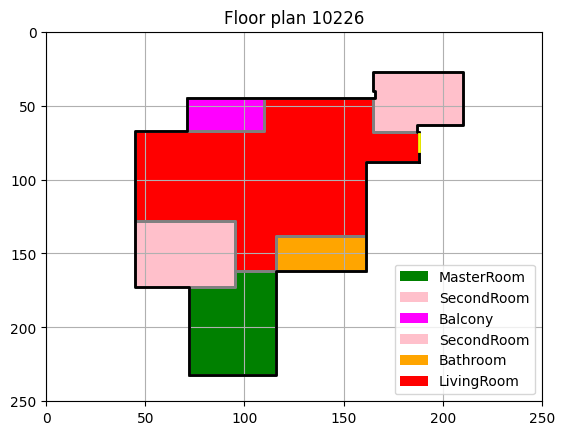

In [39]:
draw_floor_plan(no_kitchen[10])

In [40]:
from shapely.geometry import LinearRing, LineString

ring = LinearRing([(0, 0), (1, 0), (1, 1), (0, 1)])

segments = [
    LineString((a, b))
    for a, b in zip(ring.coords[:-1], ring.coords[1:])
]

segments

[<LINESTRING (0 0, 1 0)>,
 <LINESTRING (1 0, 1 1)>,
 <LINESTRING (1 1, 0 1)>,
 <LINESTRING (0 1, 0 0)>]

In [8]:
from src.losses.neighborhood_loss import NeighborhoodLoss
from src.floor_plan_tokenizer import FloorPlanTokenizer
from src.sequence import to_sequence

import numpy as np
import torch

n_loss = NeighborhoodLoss("cpu")

losses = np.empty(len(floor_plans))
tokenizer = FloorPlanTokenizer()

for i, plan in enumerate(floor_plans):
    seq = to_sequence(plan)
    seq = ''.join(seq)
    ids = tokenizer(seq)
    ids = ids['input_ids']
    ids = torch.Tensor(ids)


    losses[i] = n_loss.ergonomic_loss(ids)

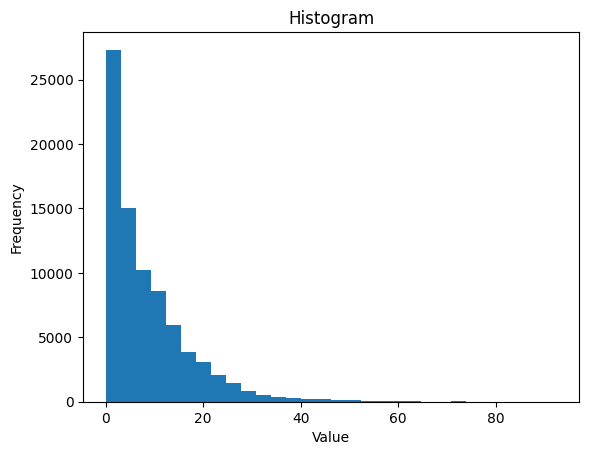

92.48893737792969


In [9]:
import matplotlib.pyplot as plt

def hist(losses):
    plt.hist(losses, bins=30)
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title("Histogram")
    plt.show()

hist(losses)

print(np.max(losses))

In [8]:
from src.losses.mean_values_loss import MeanValuesLoss
from src.floor_plan_tokenizer import FloorPlanTokenizer
from src.sequence import to_sequence

import torch

n_loss = MeanValuesLoss("cpu")

losses = np.empty(len(floor_plans))
tokenizer = FloorPlanTokenizer()

for i, plan in enumerate(floor_plans):
    seq = to_sequence(plan)
    seq = ''.join(seq)
    ids = tokenizer(seq)
    ids = ids['input_ids']
    ids = torch.Tensor(ids)


    losses[i] = n_loss.ergonomic_loss(ids)

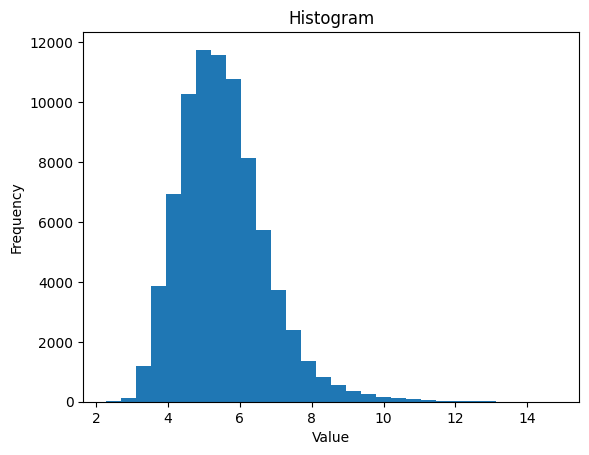

14.817700386047363


In [9]:
hist(losses)

print(np.max(losses))

In [10]:
from src.losses.segments_dist_loss import SegmentDistLoss
from src.floor_plan_tokenizer import FloorPlanTokenizer
from src.sequence import to_sequence

import torch

n_loss = SegmentDistLoss("cpu")

losses = np.empty(len(floor_plans))
tokenizer = FloorPlanTokenizer()

for i, plan in enumerate(floor_plans):
    seq = to_sequence(plan)
    seq = ''.join(seq)
    ids = tokenizer(seq)
    ids = ids['input_ids']
    ids = torch.Tensor(ids)


    losses[i] = n_loss.ergonomic_loss(ids)

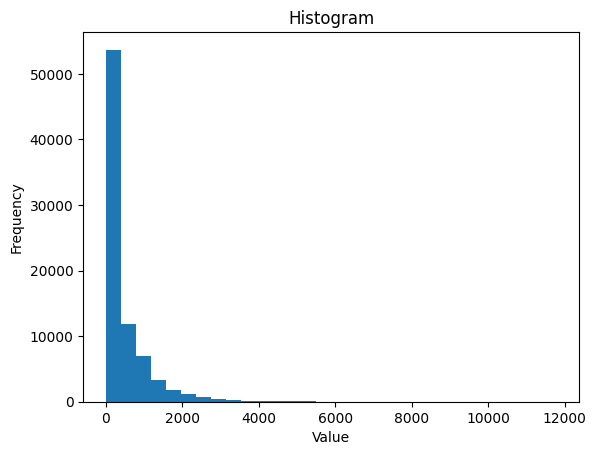

11791.25


In [11]:
hist(losses)

print(np.max(losses))

# Geometry validity

In [41]:
import shapely

In [42]:
polygon = shapely.geometry.Polygon([(0, 0), (0, 2), (2, 2), (0, 1), (2, 2), (2, 0)])

polygon.is_valid

False

In [43]:
polygon = shapely.geometry.Polygon([(0, 0), (0, 2), (1, 2), (2, 2), (2, 0)])

polygon.is_valid

True

In [44]:
list(polygon.boundary.coords)

[(0.0, 0.0), (0.0, 2.0), (1.0, 2.0), (2.0, 2.0), (2.0, 0.0), (0.0, 0.0)]

In [45]:
from src.polygons_utils import remove_collinear_points

In [46]:
new = remove_collinear_points(polygon.exterior)

list(new.coords)

[(0.0, 0.0), (0.0, 2.0), (2.0, 2.0), (2.0, 0.0), (0.0, 0.0)]

# Numbers of kitchens

In [47]:
kitchens_cnt = np.empty(len(floor_plans), dtype=np.int32)

for i, plan in enumerate(floor_plans):
    kitchens_cnt[i] = len(plan.rooms_of_type(RoomType.Kitchen))

In [48]:
np.sum(kitchens_cnt == 2)

np.int64(123)

(array([ 3146., 77136.,   123.]),
 array([0.        , 0.66666667, 1.33333333, 2.        ]),
 <BarContainer object of 3 artists>)

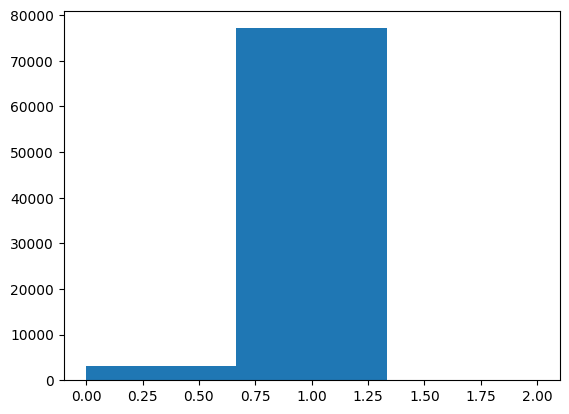

In [49]:
plt.hist(kitchens_cnt, bins=3)

# Are ccw

In [5]:
zero_width_doors = 0

for plan in floor_plans:
    if np.all(plan.front_door.corner1 == plan.front_door.corner2):
        print(plan.name)
        zero_width_doors += 1

zero_width_doors

24794


1